In [ ]:
# -----------------------------
# Import libraries
# -----------------------------

# Core
import numpy as np
import pandas as pd
import scipy
from scipy.stats import uniform

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Utilities
from itertools import cycle
from string import ascii_uppercase

# Spatial
from geopy.distance import geodesic

# Machine learning: model selection & preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Machine learning: models
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    root_mean_squared_error,
    roc_curve,
    auc,
    make_scorer
)

# XGBoost
from xgboost import XGBRegressor
import xgboost as xgb


In [54]:
# -----------------------------
# Import local functions
# -----------------------------

import sys
import os

# Get the absolute path to your src folder
module_path = os.path.abspath(os.path.join('..', 'src'))

if module_path not in sys.path:
    sys.path.append(module_path)

from cleaning_and_helpers import plot_test_preds, evaluate_model_per_project, split_project, multioutput_rmse


In [55]:
# -----------------------------
# Set random seed, also for train test split set and models set seed within function
# -----------------------------
np.random.seed(1298)
seed = 1298

In [ ]:
# ------------------------------------
# Import pre-processed train/test data
# ------------------------------------

X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')

X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

In [ ]:
# ------------------------------------
# Import project labels
# ------------------------------------
project_train = np.load('project_train.npy')
project_test = np.load('project_test.npy')

In [ ]:
# -----------------------------
# Models with best parameters
# -----------------------------

best_tuned_models = {
    "MultiTaskLasso": lambda: linear_model.MultiTaskLasso(alpha=0.08,
                                                          random_state=seed),
    "SVR": lambda: MultiOutputRegressor(SVR(C=2.847162213648956,
                                            gamma='auto',
                                            kernel='rbf')),
    "KNN": lambda: MultiOutputRegressor(KNeighborsRegressor(weights='uniform',
                                                            p=2,
                                                            n_neighbors=3,
                                                            algorithm='auto')),
    "DecisionTree": lambda: MultiOutputRegressor(DecisionTreeRegressor(min_samples_split=10,
                                                                       min_samples_leaf=2,
                                                                       max_leaf_nodes=40,
                                                                       max_features=None,
                                                                       max_depth=18,
                                                                       random_state=seed)),
    "RandomForest": lambda: MultiOutputRegressor(RandomForestRegressor(n_estimators=200,
                                                                       min_samples_split=5,
                                                                       min_samples_leaf=1,
                                                                       max_features='log2',
                                                                       max_depth=None,
                                                                       random_state=seed)),
    "XGBoost": lambda: MultiOutputRegressor(XGBRegressor(subsample=0.8,
                                                         reg_lambda=1,
                                                         reg_alpha=1,
                                                         n_estimators=500,
                                                         min_child_weight=1,
                                                         max_depth=20,
                                                         learning_rate=0.3,
                                                         gamma=0,
                                                         colsample_bytree=0.8,
                                                         random_state=seed))
}

In [ ]:
# ------------------------------------
# Compare performance between projects
# ------------------------------------

def evaluate_model_per_project(
    name,
    model_class,
    X_train,
    y_train,
    X_test,
    y_test,
    scaler=None,
    project_test=None
):
    """
    Initialize, fit, predict, and evaluate a model.
    Returns full info for plotting: predictions, true values, distances, per-project metrics.
    """
    print(f"Evaluating {name}...")

    # Get a fresh model instance
    model = model_class()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # -----------------------------
    # Inverse transform if scaler provided
    # -----------------------------
    # if scaler is not None:
    #     y_test_unscaled = y_test
    #     preds_unscaled = scaler.inverse_transform(preds)
    # else:
    #     y_test_unscaled = y_test
    #     preds_unscaled = preds

    # -----------------------------
    # Compute distance errors
    # -----------------------------
    distances = np.array([
        geodesic(real, pred).kilometers
        for real, pred in zip(y_test, preds)
    ])

    # -----------------------------
    # Compute overall metrics
    # -----------------------------
    r2 = r2_score(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    mae = median_absolute_error(y_test, preds)
    avg_dist = np.mean(distances)
    se_dist = np.std(distances)

    results = {
        "model": name,
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
        "avg_km_error": avg_dist,
        "se_km_error": se_dist,
        "y_test_unscaled": y_test,
        "preds_unscaled": preds,
        "distances": distances,
    }

    # -----------------------------
    # Add per-project metrics if given
    # -----------------------------
    if project_test is not None:
        df = pd.DataFrame({
            "y_true_lat": y_test[:, 0],
            "y_true_lon": y_test[:, 1],
            "y_pred_lat": preds[:, 0],
            "y_pred_lon": preds[:, 1],
            "project": project_test
        })

        project_metrics = []

        for project_id, group in df.groupby("project"):
            y_true_proj = group[["y_true_lat", "y_true_lon"]].values
            y_pred_proj = group[["y_pred_lat", "y_pred_lon"]].values

            r2_p = r2_score(y_true_proj, y_pred_proj)
            rmse_p = root_mean_squared_error(y_true_proj, y_pred_proj)
            mae_p = median_absolute_error(y_true_proj, y_pred_proj)
            distances_p = [
                geodesic(real, pred).kilometers
                for real, pred in zip(y_true_proj, y_pred_proj)
            ]
            avg_dist_p = np.mean(distances_p)
            se_dist_p = np.std(distances_p)

            project_metrics.append({
                "project": project_id,
                "r2": r2_p,
                "rmse": rmse_p,
                "mae": mae_p,
                "avg_km_error": avg_dist_p,
                "se_km_error": se_dist_p
            })

        results["per_project"] = project_metrics
        results["project_test"] = project_test

    return results


In [ ]:
# ----------------------------------------
# Compare between models and store results
# ----------------------------------------

results = {}

for name, model_func in best_tuned_models.items():
    result = evaluate_model_per_project(
        name,
        model_func,
        X_train,
        y_train,
        X_test,
        y_test,
        scaler=None,
        project_test=project_test  # optional if you have per-project splits
    )
    results[name] = result


Evaluating MultiTaskLasso...
Evaluating SVR...
Evaluating KNN...
Evaluating DecisionTree...
Evaluating RandomForest...
Evaluating XGBoost...


In [ ]:

# -----------------------------------------------
# Get distances & a single project label vector
# -----------------------------------------------

all_distances = []
df_models = []
project_labels = None  # <-- use None not []

for name, result in results.items():
    distances = result["distances"]
    all_distances.extend(distances)
    df_models.append((name, distances))
    
    if project_labels is None:
        project_labels = result.get("project_test", None)

if project_labels is None:
    raise ValueError("You need to pass project_test so we can label projects!")


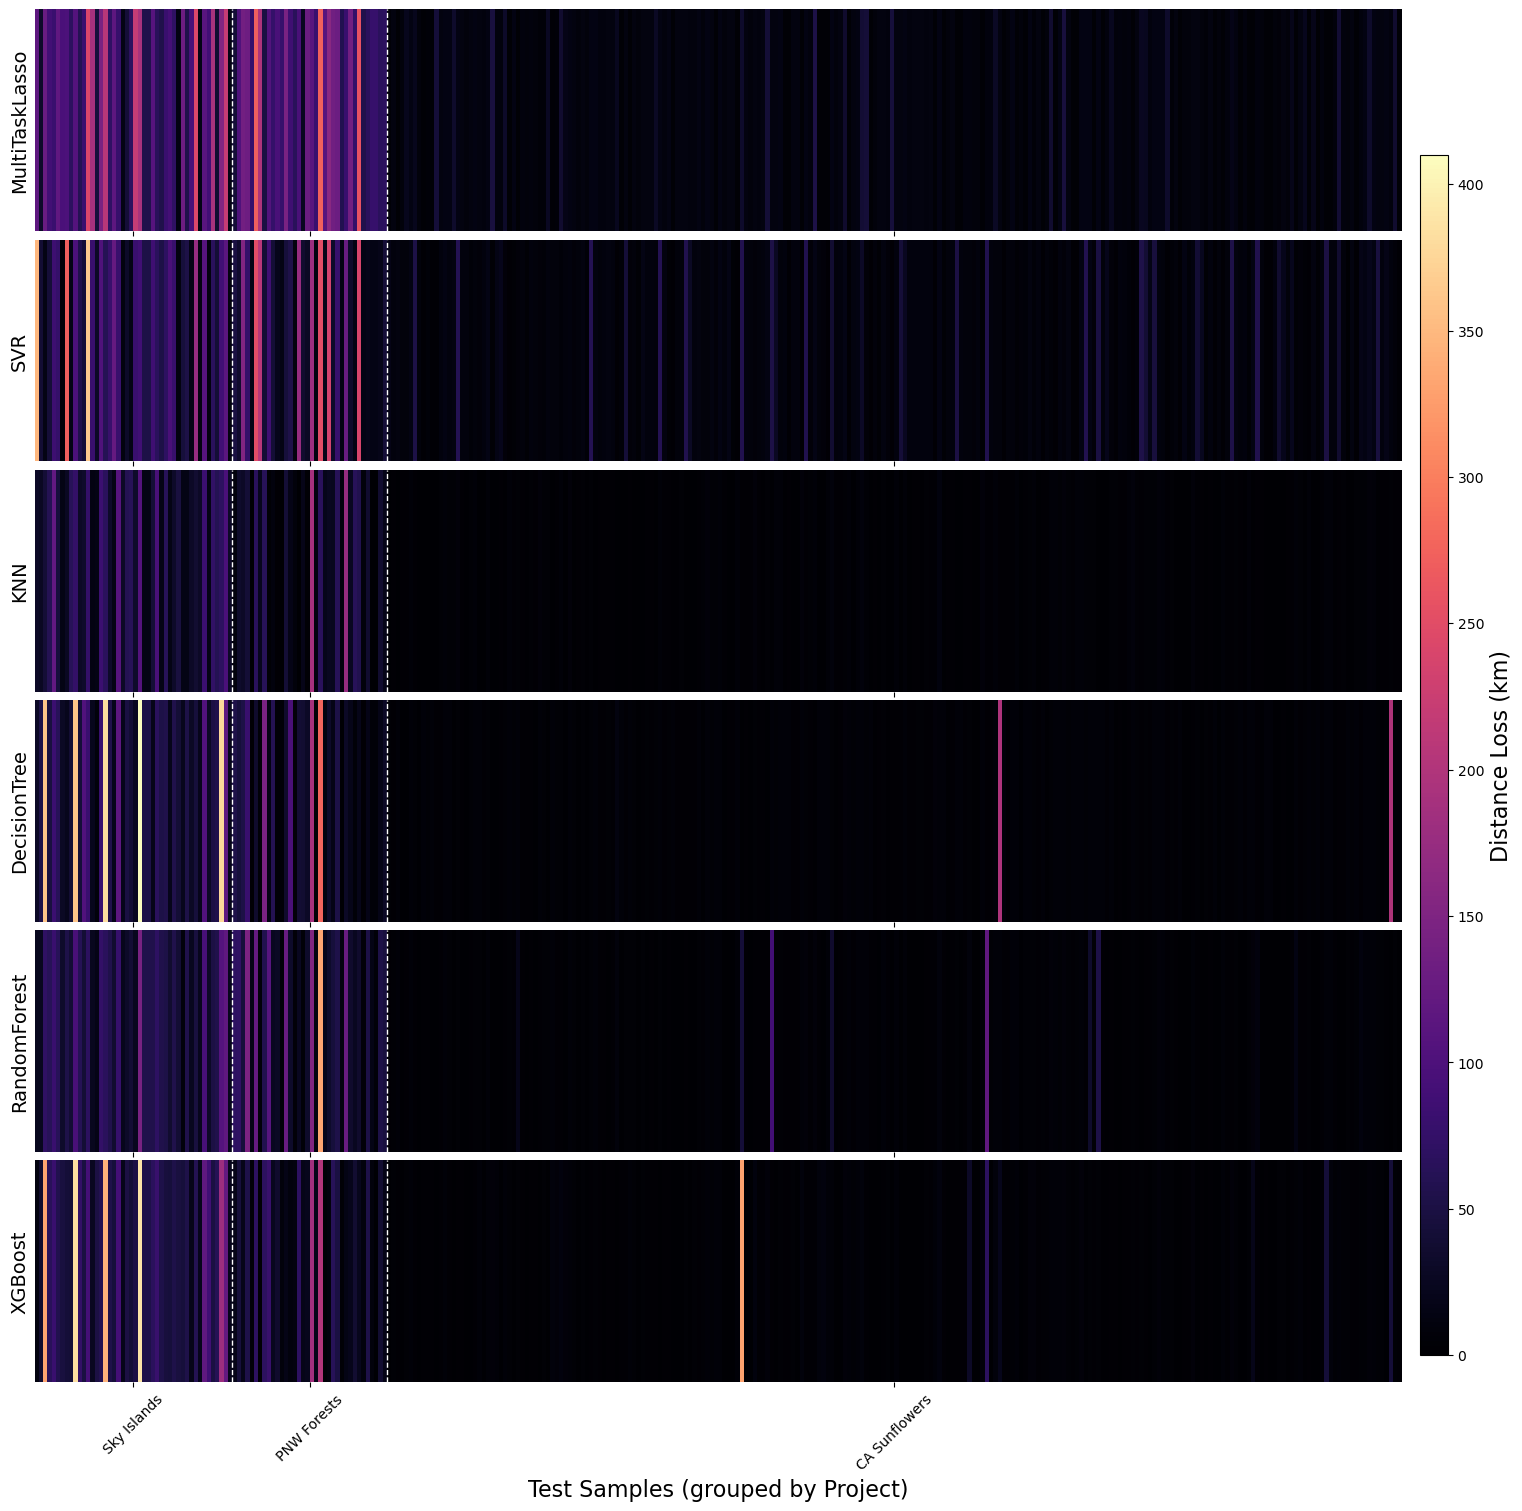

In [63]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

# -----------------------------------------------
# Get distances & a single project label vector
# -----------------------------------------------
all_distances = []
df_models = []
project_labels = None  # use None, not []

for name, result in results.items():
    distances = result["distances"]
    all_distances.extend(distances)
    df_models.append((name, distances))

    # Get project_test from the first result that has it
    if project_labels is None and "project_test" in result:
        project_labels = result["project_test"]

if project_labels is None:
    raise ValueError("You need to pass project_test so we can label projects!")

projects = np.array(project_labels)

# -----------------------------------------------
# Compute breakpoints + midpoints for labels
# -----------------------------------------------
unique_projects = []
breakpoints = []

prev_proj = None
for i, proj in enumerate(projects):
    if proj != prev_proj:
        unique_projects.append(proj)
        if prev_proj is not None:
            breakpoints.append(i)
        prev_proj = proj

breakpoints.append(len(projects))  # Add final break

midpoints = []
for start, end in zip([0] + breakpoints[:-1], breakpoints):
    midpoints.append((start + end) // 2)

# -----------------------------------------------
# Set up figure
# -----------------------------------------------
global_vmin = np.min(all_distances)
global_vmax = np.max(all_distances)
norm = mcolors.Normalize(vmin=global_vmin, vmax=global_vmax)

fig, axes = plt.subplots(
    len(df_models), 1, figsize=(14, 15),
    sharex=True, constrained_layout=True
)
cbar_ax = fig.add_axes([1.01, 0.1, 0.02, 0.8])

# Make background white and text black
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
    ax.tick_params(colors='black')         # tick labels
    for spine in ax.spines.values():
        spine.set_color('black')           # axes border
    ax.title.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.xaxis.label.set_color('black')

cbar_ax.set_facecolor('white')

# -----------------------------------------------
# Plot heatmaps with vertical lines
# -----------------------------------------------
for ax, (model_name, distances) in zip(axes, df_models):
    distances_2d = np.expand_dims(distances, axis=0)

    sns.heatmap(
        distances_2d,
        ax=ax,
        cmap="magma",
        cbar=False,
        vmin=global_vmin,
        vmax=global_vmax,
        xticklabels=False,  # we'll add our own
        yticklabels=False
    )
    ax.set_ylabel(model_name, fontsize=14)

    # Vertical lines for project boundaries
    for bp in breakpoints[:-1]:
        ax.axvline(x=bp, color="white", linestyle="--", lw=1)

# -----------------------------------------------
# Add project labels along x-axis of the bottom plot
# -----------------------------------------------
axes[-1].set_xlabel("Test Samples (grouped by Project)", fontsize=16)
axes[-1].set_xticks(midpoints)
axes[-1].set_xticklabels(unique_projects, fontsize=10, rotation=45)

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap="magma", norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Distance Loss (km)', fontsize=16, color='black')
# Make colorbar text and ticks black
cbar.ax.yaxis.set_tick_params(color='black', labelcolor='black')
for spine in cbar.ax.spines.values():
    spine.set_color('black')

plt.savefig("../../pollenGeolocation_saved/figs/tax_sample_compare_all_mods_w_projects.pdf",
            format="pdf", bbox_inches="tight")
plt.show()


In [ ]:

# -----------------------------------------------
# Plot real versus predicted location
# -----------------------------------------------

def plot_test_preds(y_test, preds, scaler, model_type, ax, norm, r2, rmse):
    # Back-transform for plotting real vs. predicted coords
    unscaled_y_test = scaler.inverse_transform(y_test)
    unscaled_preds = scaler.inverse_transform(preds)

    lat_test, lon_test = unscaled_y_test[:, 0], unscaled_y_test[:, 1]
    lat_pred, lon_pred = unscaled_preds[:, 0], unscaled_preds[:, 1]

    distances = np.array([
        geodesic((lat1, lon1), (lat2, lon2)).kilometers
        for lat1, lon1, lat2, lon2 in zip(lat_test, lon_test, lat_pred, lon_pred)
    ])

    sorted_indices = np.argsort(distances)
    lat_pred, lon_pred = lat_pred[sorted_indices], lon_pred[sorted_indices]
    lat_test_sorted, lon_test_sorted = lat_test[sorted_indices], lon_test[sorted_indices]
    distances = distances[sorted_indices]

    # SCATTER plots
    ax.scatter(lon_test_sorted, lat_test_sorted, marker='*', s=350, label='Real',
               color='gold', edgecolors='black', linewidths=0.8)
    sc = ax.scatter(lon_pred, lat_pred, c=distances, cmap='magma', alpha=0.9,
                    label='Predicted', edgecolors='black', linewidths=0.6, norm=norm)

    # Style, labels, legend...
    ax.set_facecolor('white')

    ax.tick_params(colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')

    for spine in ax.spines.values():
        spine.set_color('black')
        ax.grid(True, linestyle='--', color='lightgray', linewidth=0.5)
        ax.set_xlabel('Longitude', fontsize=12)
        ax.set_ylabel('Latitude', fontsize=12)
        leg = ax.legend(frameon=True, fontsize=10)
        leg.get_frame().set_facecolor('white')
        leg.get_frame().set_edgecolor('black')

    for text in leg.get_texts():
        text.set_color('black')
        #ax.invert_xaxis()
        #ax.invert_yaxis()

    # Use pre-computed r2 and mse
    ax.text(
        0.02, 0.25,
        f'{model_type}\n$R^2$: {r2:.2f}\nRMSE: {rmse:.2f}',
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        color='black',
        bbox=dict(
            boxstyle='round,pad=0.3',
            edgecolor='gray',
            facecolor='white')
    )

    return sc, distances


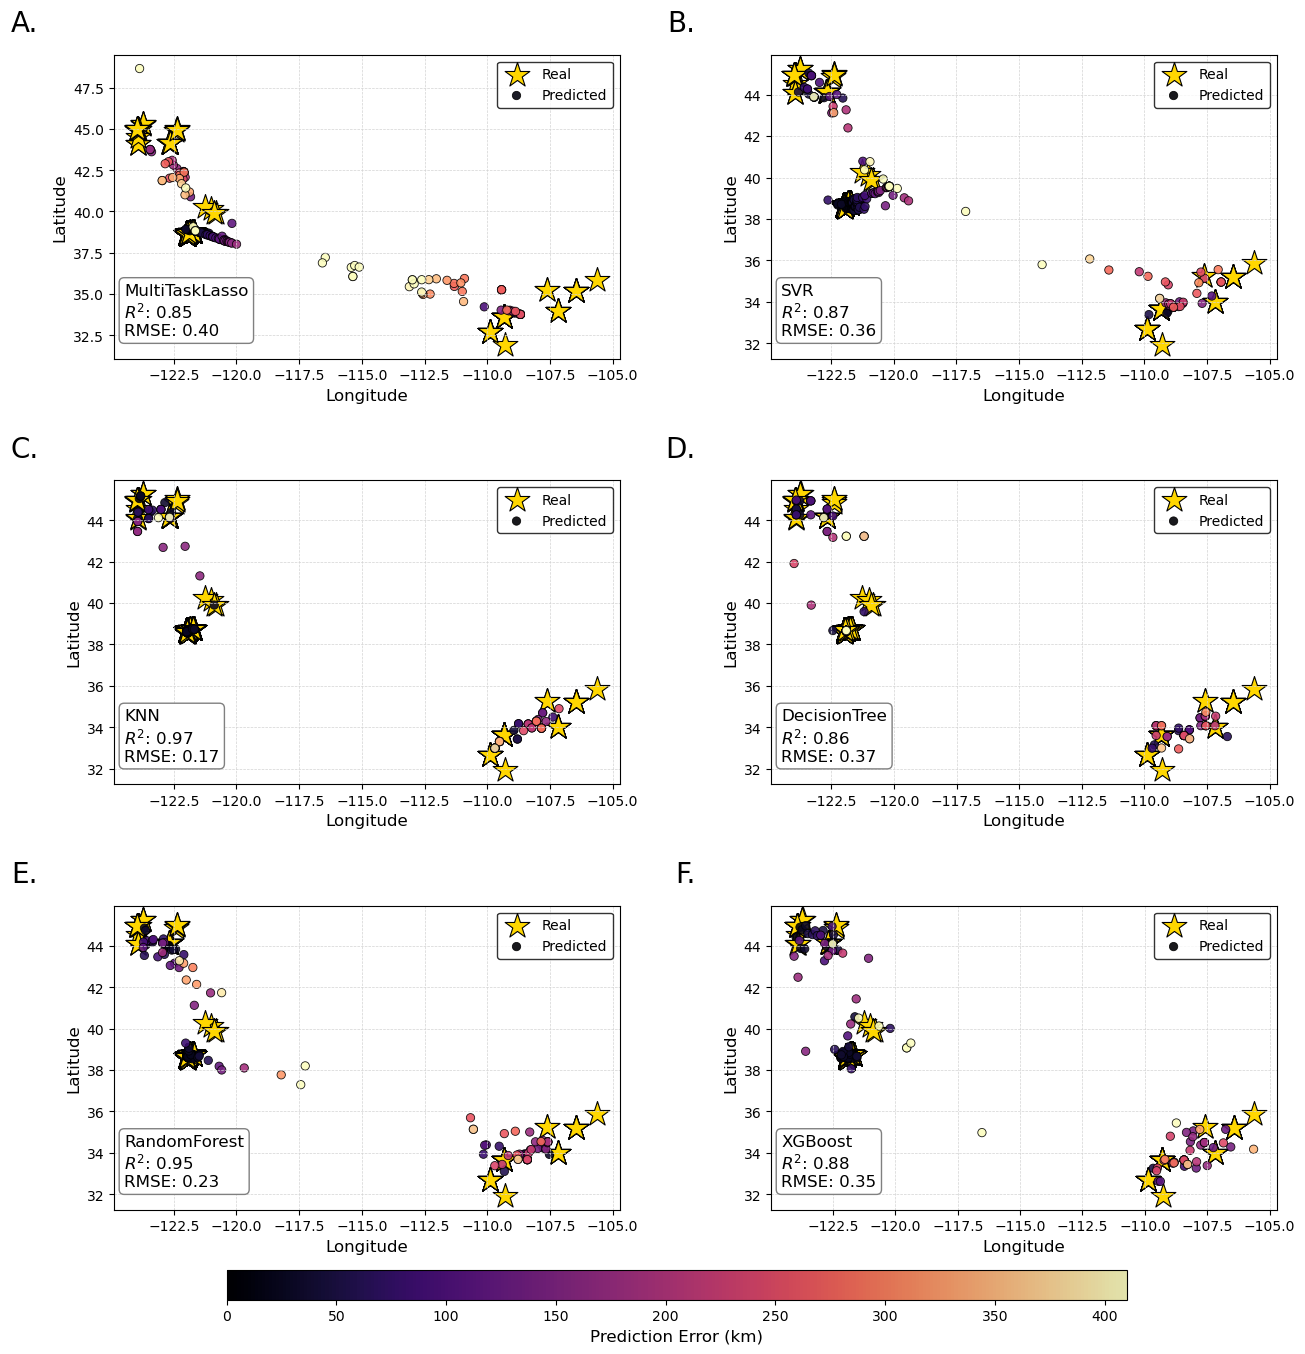

In [ ]:

# -----------------------------------------------
# Create multipanel figure
# -----------------------------------------------

# Create a 3x2 grid of subplots with adjusted spacing
fig, axes = plt.subplots(3, 2, figsize=(15, 15), facecolor='white')  # Increased width for better spacing
axes = axes.flatten()  # Flatten the 2D array for easy iteration

sc_list = []  # Store scatter objects for colorbar reference

# Iterate over method_dict to access both model_type and associated preds
sc_list = []

for i, (model_type, model_result) in enumerate(results.items()):
    preds = model_result["preds_unscaled"]
    r2 = model_result["r2"]
    rmse = model_result["rmse"]

    ax = axes[i]
    sc, _ = plot_test_preds(y_test, preds, sc_y, model_type, ax=ax, norm=norm, r2=r2, rmse=rmse)
    sc_list.append(sc)

    ax.text(
        -0.15, 1.15,
        f"{ascii_uppercase[i]}.",
        transform=ax.transAxes,
        color='black',
        fontsize=20,
        va='top',
        ha='right'
    )



# Adjust subplot spacing to create a small gap between columns
plt.subplots_adjust(wspace=0.3, hspace=0.4)  # `wspace` increases horizontal gap

# Add a single horizontal colorbar across the bottom
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])
cbar = plt.colorbar(sc_list[-1], cax=cbar_ax, orientation="horizontal")

cbar.set_label('Prediction Error (km)', fontsize=12, color='black')
cbar.ax.tick_params(colors='black', labelcolor='black')
cbar.outline.set_edgecolor('black')


# Save the plot as a PDF
plt.savefig("../../pollenGeolocation_saved/figs/tax_real_vs_pred_scatterplots_normalized.pdf", format="pdf")

plt.show()


In [ ]:
# -------------------------------------------------
# determining feature importance for random forests
# -------------------------------------------------

rf =MultiOutputRegressor(RandomForestRegressor(n_estimators = 200,
                          min_samples_split = 5,
                          min_samples_leaf = 1, 
                          max_features = 'log2', 
                          max_depth = None)) 

rf = rf.fit(X_train,y_train)
pred_train = rf.predict(X_train)
pred_test = rf.predict(X_test)

In [ ]:
# -------------------------------------------------
# Load feature column names
# -------------------------------------------------

names = np.load('X_columns_tax.npy', allow_pickle=True)

In [ ]:
# -------------------------------------------------
# Arrange into dataframe and pair with labels
# -------------------------------------------------

all_importances = np.vstack([estimator.feature_importances_ for estimator in rf.estimators_]).T
importance_df = pd.DataFrame(all_importances, index=names, columns=[f"Output_{i}" for i in range(len(rf.estimators_))])
importance_df


,Output_0,Output_1
RBCL:Achillea_millefolium,1.154271e-03,3.128930e-03
RBCL:Achillea_sp,3.458633e-02,5.619962e-03
RBCL:Acmispon_glaber,3.757793e-05,1.170090e-05
RBCL:Actinidia_arguta,3.106935e-08,8.544876e-09
RBCL:Adenostoma_fasciculatum,3.401483e-05,4.683199e-06
...,...,...
RBCL:Vicia_americana,1.678643e-02,2.525717e-02
RBCL:Vicia_cirrhosa,3.186791e-03,3.508168e-04
RBCL:Vicia_sp,9.784696e-04,3.066404e-04
RBCL:Zinnia_elegans,1.064781e-03,2.752169e-03


In [ ]:
# --------------------------------------------------
# Get top feature importances for lat and long preds
# --------------------------------------------------

top_n = 25
top_features = {}

for col in importance_df.columns:
    top_features[col] = (
        importance_df[col]
        .sort_values(ascending=False)
        .head(top_n)
    )


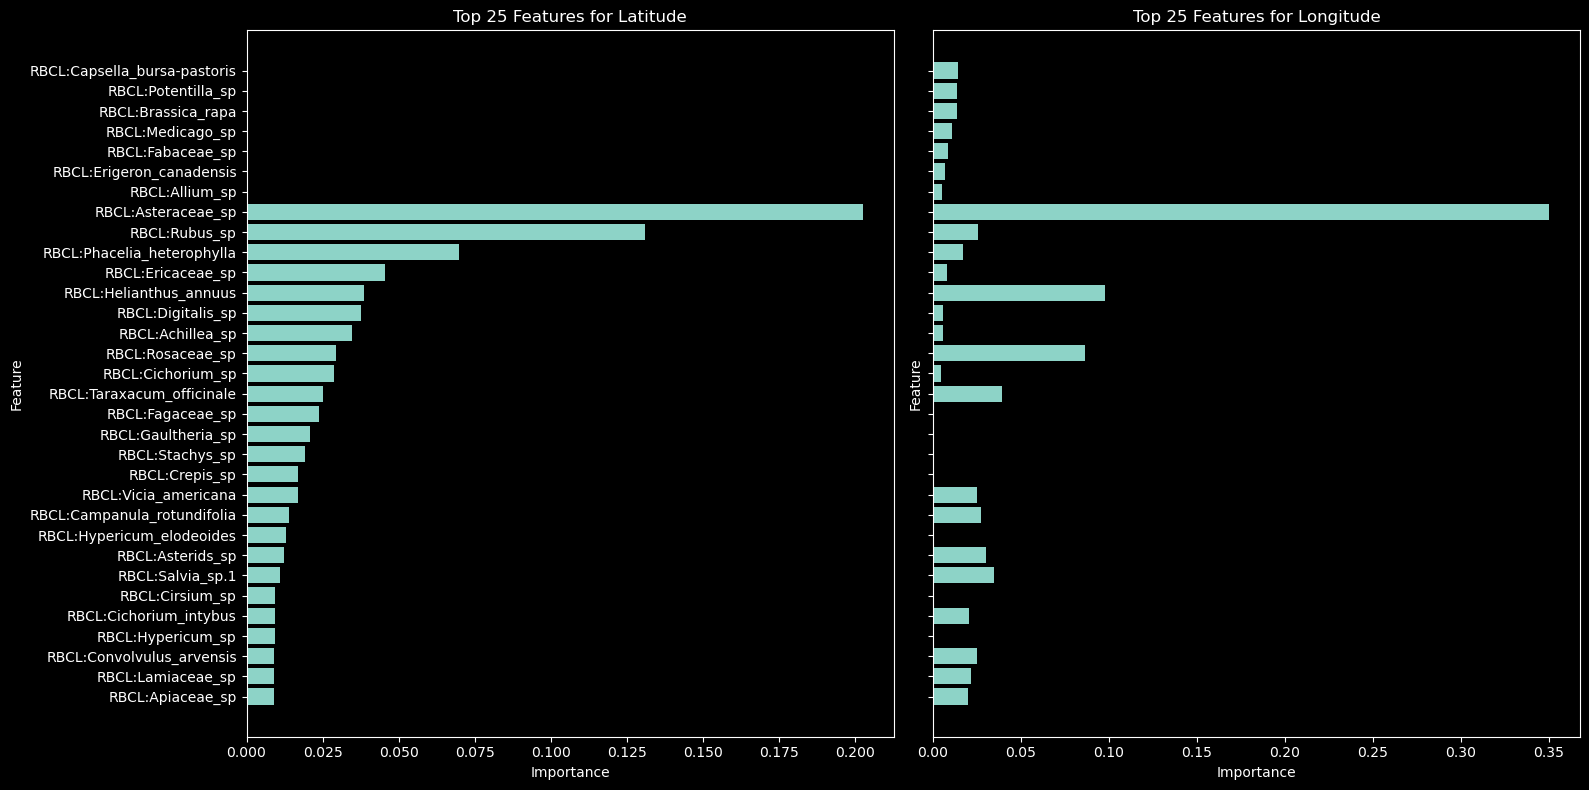

In [ ]:
# ------------------------------------------------------------
# Create multipanel figure for lat and long feature importance
# ------------------------------------------------------------

output_labels = {
    "Output_0": "Latitude",
    "Output_1": "Longitude"
}

# Create subplots for 2 outputs
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for i, (output_name, importances) in enumerate(top_features.items()):
    ax = axes[i]
    importances = importances.sort_values()  # So the bars go from low to high
    ax.barh(importances.index, importances.values)
    ax.set_title(f"Top {top_n} Features for {output_labels.get(output_name, output_name)}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()
